In [1]:
import cv2
from matplotlib import pyplot as plt

from src.comparison import CalulateMetricsFromModelPredict
from src.prepare_data import plug_old_connect_res_test_data
from src.test import getPipliner, test_data
from src.prepare_data import to_0_1_format_img

In [2]:
import os
for name in os.listdir("test_data/img_in"):
    print(name)

testing0000.png
testing0001.png
testing0002.png
testing0056.png
testing0057.png
testing0058.png
testing0059.png
testing0110.png
testing0162.png
testing0163.png


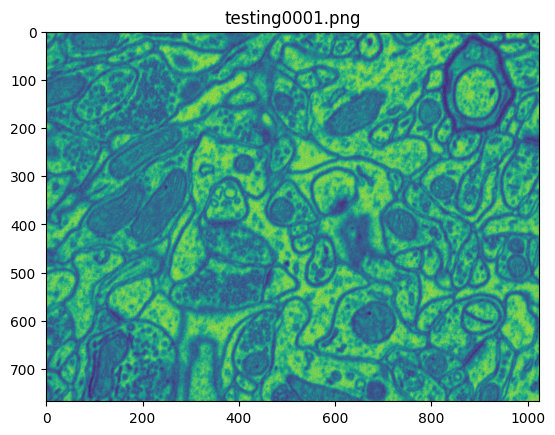

In [3]:
img_name = "testing0001.png"
img_for_test = cv2.imread(f"test_data/img_in/{img_name}", 0)
plt.title(img_name)
plt.imshow(img_for_test)
dataset_for_predict = [([to_0_1_format_img(img_for_test)], [img_name])]

In [4]:
import os
for name in os.listdir("test_data/model_data"):
    if name.startswith("model"):
        print(name)

model_by_config_diffusion_data_42_slices_6_classes_dataset_diff_6_classes_seed_2137103169_tiny_unet_v3.pth
model_by_config_diffusion_data_42_slices_6_classes_dataset_mix_6_classes_seed_1466947709_tiny_unet_v3.pth


In [5]:
model, name_model = getPipliner("test_data/model_data/",
                                "config_diffusion_data_42_slices_6_classes_dataset_mix_6_classes_seed_1466947709_tiny_unet_v3",
                               device='cpu')
print(name_model)
print(model.device)

NameError: name 'activation_parcer' is not defined

In [ ]:
tiling_mode = True
tiled_data = {"size": 256, "overlap": 128, "unique_area": 0} if tiling_mode else None
class_names=[
        "mitochondria",
        "PSD",
        "vesicles",
        "axon",
        "boundaries",
        "mitochondrial boundaries"
        ]


predict_img_list, predict_name_list = test_data(model,
                                                dataset_for_predict,
                                                save_mask_dir=None,
                                                tiled_data=tiled_data,
                                                batch_size=1
                                                )

predict_for_check = plug_old_connect_res_test_data(predict_img_list, predict_name_list)

result_metrics_merge,\
text_result_merge,\
text_result_merge_all = CalulateMetricsFromModelPredict(predict_for_check,
                                                        name_model,
                                                        6,
                                                        etal_path="test_data/img_etal",
                                                        class_names=class_names,
                                                        using_metric_names=["Dice", "Jaccard"],
                                                        merge_images=True,
                                                        is_print_metric=False
                                                        )
result_metrics_merge


In [ ]:
for i, img in enumerate(predict_img_list):
    fig, axs  = plt.subplots(2, 3)
    fig.suptitle(f"predict {predict_name_list[i]}")
    for y in range(2):
        for x in range(3):
            c_i = y*3+x
            classname = class_names[c_i]

            # изображения масок в диапозоне [0-255]
            axs [y, x].imshow(img[:,:,c_i])
            axs [y, x].set_title(classname)

            #print(img[:,:,c_i])

        
    